In [1]:
!pip install transformers datasets pandas scikit-learn

In [2]:
!pip install transformers datasets scikit-learn seaborn gradio --quiet

In [3]:
import pandas as pd
import numpy as np
df = pd.read_csv('/content/amazon.csv')
import warnings
warnings.filterwarnings('ignore')
print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head(3)

Shape: (1465, 16)
Columns: ['product_id', 'product_name', 'category', 'discounted_price', 'actual_price', 'discount_percentage', 'rating', 'rating_count', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...


In [4]:
df = df[pd.to_numeric(df['rating'], errors='coerce').notna()].copy()
df['rating'] = df['rating'].astype(float)

In [5]:
df = df.dropna(subset=['review_content'])

In [6]:
def get_label(r):
    if r <= 2.9:
      return 'negative'
    elif r <= 3.5:
      return 'neutral'
    else:
      return 'positive'

df['sentiment'] = df['rating'].apply(get_label)

In [7]:
print(f'Clean dataset: {len(df)} rows')
print()
print('Sentiment distribution:')
print(df['sentiment'].value_counts())

Clean dataset: 1464 rows

Sentiment distribution:
sentiment
positive    1396
neutral       62
negative       6
Name: count, dtype: int64


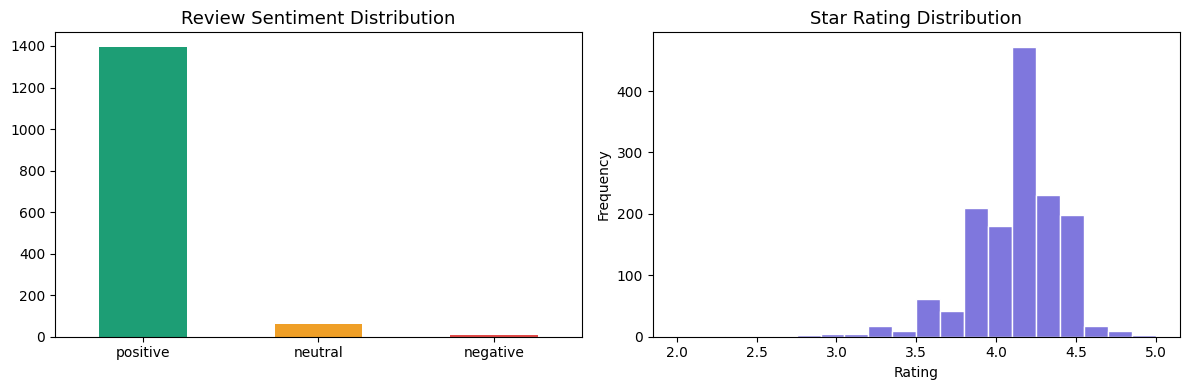

Charts displayed!


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {'negative': '#E24B4A', 'neutral': '#EF9F27', 'positive': '#1D9E75'}
df['sentiment'].value_counts().plot(kind='bar', ax=axes[0],
    color=[colors[c] for c in df['sentiment'].value_counts().index],
    edgecolor='none')
axes[0].set_title('Review Sentiment Distribution', fontsize=13)
axes[0].set_xlabel('')
axes[0].tick_params(rotation=0)

df['rating'].plot(kind='hist', bins=20, ax=axes[1], color='#7F77DD', edgecolor='white')
axes[1].set_title('Star Rating Distribution', fontsize=13)
axes[1].set_xlabel('Rating')

plt.tight_layout()
plt.show()
print('Charts displayed!')

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [10]:
X = df['review_content']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training examples: {len(X_train)}')
print(f'Testing examples:  {len(X_test)}')

Training examples: 1171
Testing examples:  293


In [11]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)

In [12]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [13]:
preds = lr_model.predict(X_test_vec)
baseline_acc = accuracy_score(y_test, preds)

In [14]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset

label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label = {0: 'negative', 1: 'neutral', 2: 'positive'}

In [15]:
train_df = pd.DataFrame({'text': X_train.values, 'label': [label2id[l] for l in y_train]})
test_df  = pd.DataFrame({'text': X_test.values,  'label': [label2id[l] for l in y_test]})

In [16]:
train_dataset = Dataset.from_pandas(train_df)
test_dataset  = Dataset.from_pandas(test_df)

print(train_dataset)

Dataset({
    features: ['text', 'label'],
    num_rows: 1171
})


In [17]:
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [18]:
def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=128)

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

print('Tokenization done!')

Map:   0%|          | 0/1171 [00:00<?, ? examples/s]

Map:   0%|          | 0/293 [00:00<?, ? examples/s]

Tokenization done!


In [19]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [20]:
training_args = TrainingArguments(
    output_dir='./sentiment_model',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    logging_steps=10,
    warmup_steps=50,
    weight_decay=0.01,
    report_to='none'
)

In [21]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = (predictions == labels).mean()
    return {'accuracy': acc}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print('Model ready to train!')

Model ready to train!


In [22]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.229665,0.211721,0.952218
2,0.174499,0.219764,0.952218
3,0.173490,0.205295,0.952218


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=222, training_loss=0.2656841839890222, metrics={'train_runtime': 58.6608, 'train_samples_per_second': 59.887, 'train_steps_per_second': 3.784, 'total_flos': 116341567619328.0, 'train_loss': 0.2656841839890222, 'epoch': 3.0})

In [23]:
results = trainer.evaluate()
bert_acc = results['eval_accuracy']

print('=' * 45)
print('MODEL COMPARISON')
print('=' * 45)
print(f'  TF-IDF + Logistic Regression: {baseline_acc:.2%}')
print(f'  DistilBERT (fine-tuned):       {bert_acc:.2%}')
print('=' * 45)
improvement = bert_acc - baseline_acc
print(f'  DistilBERT is {improvement:.2%} better')

Training Loss,Validation Loss,Epoch,Accuracy
0.173490,0.205295,3,0.952218


MODEL COMPARISON
  TF-IDF + Logistic Regression: 95.22%
  DistilBERT (fine-tuned):       95.22%
  DistilBERT is 0.00% better


In [24]:
model.save_pretrained('./my_sentiment_model')
tokenizer.save_pretrained('./my_sentiment_model')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./my_sentiment_model/tokenizer_config.json',
 './my_sentiment_model/tokenizer.json')

In [25]:
import gradio as gr
from transformers import pipeline

sentiment_pipeline = pipeline(
    'text-classification',
    model='./my_sentiment_model',
    tokenizer='./my_sentiment_model'
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [26]:
emoji_map = {'negative': '😠 Negative', 'neutral': '😐 Neutral', 'positive': '😊 Positive'}

def predict_sentiment(review_text):
    if not review_text.strip():
        return 'Please enter a review!', ''
    result = sentiment_pipeline(review_text[:512])[0]
    label = result['label']
    confidence = result['score']
    display = emoji_map.get(label, label)
    confidence_str = f'Confidence: {confidence:.1%}'
    return display, confidence_str

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=4,
        placeholder='Paste an Amazon review here... ex: The cable stopped working after 2 weeks.',
        label='Review Text'
    ),
    outputs=[
        gr.Textbox(label='Predicted Sentiment'),
        gr.Textbox(label='Confidence Score')
    ],
    title='SentimentScope — Amazon Review Analyser',
    description='Fine-tuned DistilBERT on Amazon India product reviews. Enter any review to analyse its sentiment.',
    examples=[
        ['This product is absolutely amazing! Fast charging and great build quality.'],
        ['Stopped working after 3 days. Very disappointed with the quality.'],
        ['It is okay, nothing special but does the job.']
    ]
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6eb879916c768a5748.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
